In [1]:
import torch
import os
from utilities import *
device = torch.device('cpu')
import matplotlib.pyplot as plt
print(device)

cpu


c:\Users\runan\kan-robustness-scaling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parameters

ranges = [-1, 1]
n_train = 1000
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50, 100]
k=3
lr=1
dimensions = [5, 10, 20, 50, 100, 200, 500, 1000]
seeds = [0, 1, 42]

In [ ]:
def train_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}

    for seed in seeds:
        
        static_kan_results = {}
        dyn_kan_results = {}
        mlp_results = {}
        
        for d in dimensions:
            dataset_path = os.path.join("datasets", f'seed {seed}', f'{data}_dataset_dim{d}_seed{seed}.pt')
            if os.path.exists(dataset_path):
                dataset = torch.load(dataset_path, map_location='cpu')
            else:
                dataset = generate_dataset(d, data, seed, n_train, n_test, device=torch.device('cpu'), ranges=ranges)
            width = [d, 1, 1]
            kan_param = (width[0] * width[1] * (grids[0] + k + 3) + width[1]) + (width[1] * width[2] * (grids[0] + k + 3) + width[2])
            mlp_hidden_width = math.ceil((10*d+11)/(d+2)) - 1

            static_kan_results[d] = train_kan(width=width, dataset=dataset, static=True, seed=seed, steps=steps,grids=grids, lr=lr, k=k)
            dyn_kan_results[d] = train_kan(width=width, dataset=dataset, static=False, seed=seed, steps=steps, grids=grids, lr=lr, k=k)
            mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset, seed=seed, steps=steps, lr=lr)
            mlp_param = mlp_results[d]['param_counts']
            print(f"Dimension {d}: KAN params: {kan_param}, MLP params: {mlp_param}")
        
        static_kan[seed] = static_kan_results
        dyn_kan[seed] = dyn_kan_results
        mlp[seed] = mlp_results
    
        output_dir = os.path.join("3-results", f'{steps}-epochs-seed-{seed}')
        os.makedirs(output_dir, exist_ok=True)
        torch.save(static_kan, os.path.join(output_dir, f'static_kan_{data}.pt'))
        torch.save(dyn_kan, os.path.join(output_dir, f'dyn_kan_{data}.pt'))
        torch.save(mlp, os.path.join(output_dir, f'mlp_{data}.pt'))
    return static_kan, dyn_kan, mlp


In [ ]:
static_kan_A, dyn_kan_A, mlp_A = train_all_seeds('A')

In [ ]:
static_kan_B, dyn_kan_B, mlp_B = train_all_seeds('B')

In [ ]:
static_kan_C, dyn_kan_C, mlp_C = train_all_seeds('C')

In [15]:
def plot_r2s_rmses_all(static_list, dyn_list, mlp_list, dimensions, seeds, labels, plot_mlp=True, cutoff = 3):
    plt.rcParams.update({
        'font.size': 13,          # Global base size
        'axes.titlesize': 16,     # Subplot titles
        'axes.labelsize': 14,     # X and Y axis labels
        'xtick.labelsize': 12,    # X-tick labels
        'ytick.labelsize': 12,    # Y-tick labels
        'legend.fontsize': 15,    # Legend font
        'figure.titlesize': 18    # Main suptitle
    })
    
    n = len(labels)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8), sharex='col')
    if n == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    def mean_err(results_all_seeds, dimensions, seeds, key):
        means = []
        mins = []
        maxs = []
        for d in dimensions:
            final_vals = np.array([results_all_seeds[seed][d][key][-1] for seed in seeds])
            means.append(np.mean(final_vals))
            mins.append(np.min(final_vals))
            maxs.append(np.max(final_vals))
        return np.array(means), np.array(mins), np.array(maxs)

    for i, lab in enumerate(labels):
        static_kan = static_list[i]
        dyn_kan = dyn_list[i]
        mlp = mlp_list[i] 
        
        static_means_r2, static_mins_r2, static_maxs_r2 = mean_err(static_kan, dimensions, seeds, 'r2s')
        dyn_means_r2, dyn_mins_r2, dyn_maxs_r2 = mean_err(dyn_kan, dimensions, seeds, 'r2s')
        mlp_means_r2, mlp_mins_r2, mlp_maxs_r2 = mean_err(mlp, dimensions, seeds, 'r2s')
        
        static_means_rmse, static_mins_rmse, static_maxs_rmse = mean_err(static_kan, dimensions, seeds, 'rmses')
        dyn_means_rmse, dyn_mins_rmse, dyn_maxs_rmse = mean_err(dyn_kan, dimensions, seeds, 'rmses')
        mlp_means_rmse, mlp_mins_rmse, mlp_maxs_rmse = mean_err(mlp, dimensions, seeds, 'test_loss')

        ax_rmse = axes[0, i]
        ax_r2 = axes[1, i]

        ax_rmse.plot(dimensions, static_means_rmse, marker='s', linestyle='-', alpha=0.9, label='Static KAN', color='tab:blue')
        ax_rmse.fill_between(dimensions, static_mins_rmse, static_maxs_rmse, alpha=0.2, color='tab:blue')
        
        ax_rmse.plot(dimensions, dyn_means_rmse, marker='^', linestyle='-', alpha=0.9, label='Dynamic KAN', color='tab:orange')
        ax_rmse.fill_between(dimensions, dyn_mins_rmse, dyn_maxs_rmse, alpha=0.2, color='tab:orange')
        
        if plot_mlp:
            ax_rmse.plot(dimensions, mlp_means_rmse, marker='o', linestyle='-', alpha=0.9, label='MLP', color='tab:green')
            ax_rmse.fill_between(dimensions, mlp_mins_rmse, mlp_maxs_rmse, alpha=0.2, color='tab:green')

        ax_r2.plot(dimensions, static_means_r2, marker='s', linestyle='-', alpha=0.9, color='tab:blue')
        ax_r2.fill_between(dimensions, static_mins_r2, static_maxs_r2, alpha=0.2, color='tab:blue')
        
        ax_r2.plot(dimensions, dyn_means_r2, marker='^', linestyle='-', alpha=0.9, color='tab:orange')
        ax_r2.fill_between(dimensions, dyn_mins_r2, dyn_maxs_r2, alpha=0.2, color='tab:orange')
        
        if plot_mlp:
            ax_r2.plot(dimensions, mlp_means_r2, marker='o', linestyle='-', alpha=0.9, color='tab:green')
            ax_r2.fill_between(dimensions, mlp_mins_r2, mlp_maxs_r2, alpha=0.2, color='tab:green')

        ax_rmse.set_xscale('log')
        ax_rmse.set_xticks(dimensions)
        ax_rmse.set_xticklabels(dimensions)
        ax_rmse.set_yscale('log')
        ax_rmse.set_title(f'$f_{lab}$')
        
        ax_r2.set_xscale('log')
        ax_r2.set_xlabel('dimensions (log)')
        ax_r2.set_xticks(dimensions)
        ax_r2.set_xticklabels(dimensions)
        ax_r2.set_yscale('symlog')

        lowest_allowed = min(
            np.min(static_mins_r2),
            np.min(dyn_mins_r2),
            np.min(mlp_mins_r2) if plot_mlp else np.min(static_mins_r2)
        )

        custom_ticks = []
        custom_labels = []
        auto_ymin = -1.0

        if lowest_allowed < 0:
            max_power = int(np.ceil(np.log10(abs(lowest_allowed))))
            auto_ymin = -(10**max_power) * 1.1
            for p in range(max_power, -1, -1):
                custom_ticks.append(-(10**p))
                custom_labels.append(f"$-10^{p}$")

        custom_ticks.extend([0, 1])
        custom_labels.extend(["0", "1"]) 

        ax_r2.set_ylim(auto_ymin, 1.3)
        ax_r2.set_yticks(custom_ticks)
        ax_r2.set_yticklabels(custom_labels)

        if i == 0:
            ax_rmse.set_ylabel('RMSE (log)')
            ax_r2.set_ylabel('R2 Score (symlog)')
        else:
            ax_rmse.set_ylabel('')
            ax_r2.set_ylabel('')

    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)
    fig.suptitle('KAN vs MLP ($R^2$ Score)', y=0.93)
    
    # Adjusted rect to expand the plots vertically into the old empty padding areas
    plt.tight_layout(rect=[0, 0.05, 1, 0.90])
    plt.savefig(f"dimensionality-{'_'.join(labels)}.png", bbox_inches='tight', dpi=300)
    plt.show()

In [9]:
def load_all_results(steps, data_types):
  
    results = {}
    results_dir = "4-results"
    seed_dirs = []
    
    for item in os.listdir(results_dir):
        if f'{steps}-epochs-seed-' in item:
            seed_dirs.append(item)
    
    seed_dirs.sort()
    
    for data_type in data_types:
        static_kan_all = {}
        dyn_kan_all = {}
        mlp_all = {}
        
        for seed_dir in seed_dirs:
            seed = int(seed_dir.split('-')[-1])
            
            dir_path = os.path.join(results_dir, seed_dir)
            static_path = os.path.join(dir_path, f'static_kan_{data_type}.pt')
            dyn_path = os.path.join(dir_path, f'dyn_kan_{data_type}.pt')
            mlp_path = os.path.join(dir_path, f'mlp_{data_type}.pt')
            
            if os.path.exists(static_path):
                static_kan_all.update(torch.load(static_path, weights_only=False))
                print(f"Loaded Static KAN {data_type} from seed {seed}")
            if os.path.exists(dyn_path):
                dyn_kan_all.update(torch.load(dyn_path, weights_only=False))
                print(f"Loaded Dynamic KAN {data_type} from seed {seed}")
            if os.path.exists(mlp_path):
                mlp_all.update(torch.load(mlp_path, weights_only=False))
                print(f"Loaded MLP {data_type} from seed {seed}")
        
        results[data_type] = {
            'static_kan': static_kan_all,
            'dyn_kan': dyn_kan_all,
            'mlp': mlp_all
        }
    
    return results

results = load_all_results(200, ['A', 'B', 'C'])


Loaded Static KAN A from seed 0
Loaded Dynamic KAN A from seed 0
Loaded MLP A from seed 0
Loaded Static KAN A from seed 1
Loaded Dynamic KAN A from seed 1
Loaded MLP A from seed 1
Loaded Static KAN A from seed 42
Loaded Dynamic KAN A from seed 42
Loaded MLP A from seed 42
Loaded Static KAN A from seed 0
Loaded Dynamic KAN A from seed 0
Loaded MLP A from seed 0
Loaded Static KAN A from seed 1
Loaded Dynamic KAN A from seed 1
Loaded MLP A from seed 1
Loaded Static KAN A from seed 42
Loaded Dynamic KAN A from seed 42
Loaded MLP A from seed 42
Loaded Static KAN B from seed 0
Loaded Dynamic KAN B from seed 0
Loaded MLP B from seed 0
Loaded Static KAN B from seed 1
Loaded Dynamic KAN B from seed 1
Loaded Static KAN B from seed 0
Loaded Dynamic KAN B from seed 0
Loaded MLP B from seed 0
Loaded Static KAN B from seed 1
Loaded Dynamic KAN B from seed 1
Loaded MLP B from seed 1
Loaded Static KAN B from seed 42
Loaded Dynamic KAN B from seed 42
Loaded MLP B from seed 42
Loaded Static KAN C from s

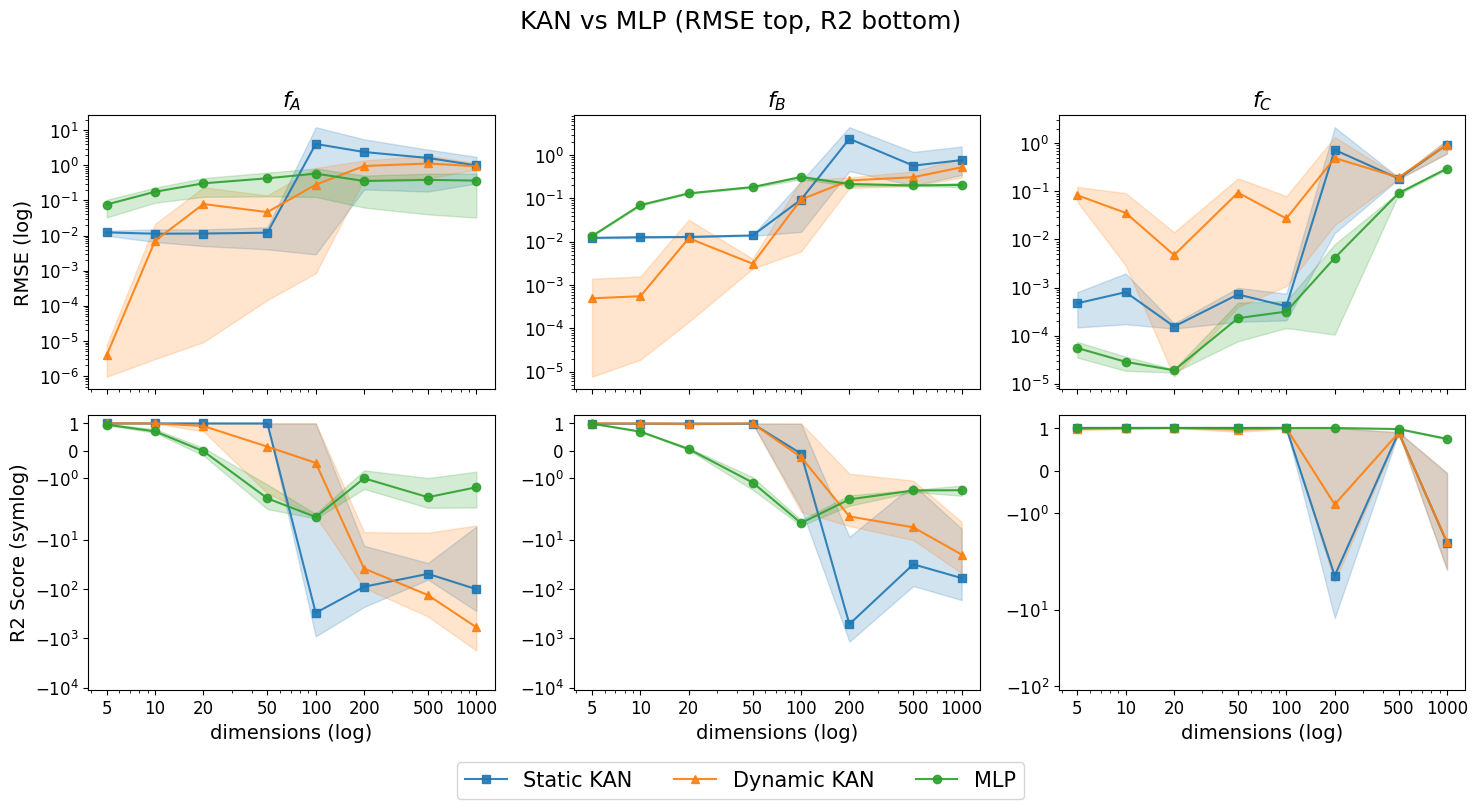

In [16]:
plot_r2s_rmses_all(
    [results['A']['static_kan'], results['B']['static_kan'], results['C']['static_kan']],
    [results['A']['dyn_kan'], results['B']['dyn_kan'], results['C']['dyn_kan']],
    [results['A']['mlp'], results['B']['mlp'], results['C']['mlp']],
    dimensions,
    seeds,
    ['A', 'B', 'C'],
    plot_mlp=True,
    cutoff=3
)


## Code blocks below are supplementary figures only

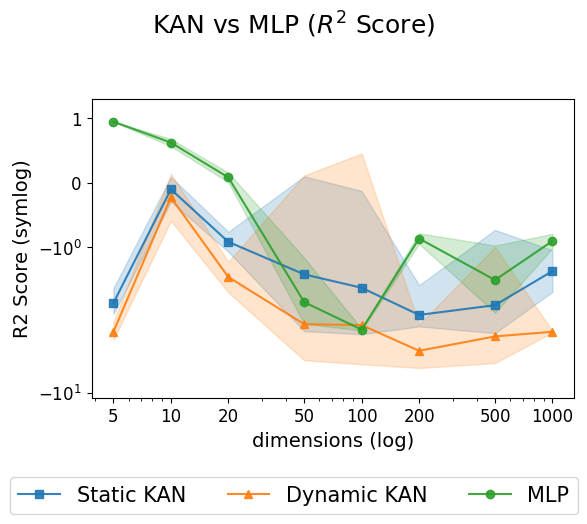

In [ ]:

# Load Adam-optimizer results from 4-results-adam and plot Dataset A with seed shading

def load_adam_results(steps, data_types, results_dir="4-results-adam"):
    results = {}
    seed_dirs = [item for item in os.listdir(results_dir) if item.startswith(f"{steps}-epochs-seed-")]
    seed_dirs = [item for item in seed_dirs if os.path.isdir(os.path.join(results_dir, item))]
    seed_dirs.sort()

    for data_type in data_types:
        static_kan_all = {}
        dyn_kan_all = {}
        mlp_all = {}

        for seed_dir in seed_dirs:
            seed = int(seed_dir.split('-')[-1])
            dir_path = os.path.join(results_dir, seed_dir)
            static_path = os.path.join(dir_path, f'static_kan_{data_type}.pt')
            dyn_path = os.path.join(dir_path, f'dyn_kan_{data_type}.pt')
            mlp_path = os.path.join(dir_path, f'mlp_{data_type}.pt')

            if os.path.exists(static_path):
                static_kan_all.update(torch.load(static_path, weights_only=False))
            if os.path.exists(dyn_path):
                dyn_kan_all.update(torch.load(dyn_path, weights_only=False))
            if os.path.exists(mlp_path):
                mlp_all.update(torch.load(mlp_path, weights_only=False))

        results[data_type] = {
            'static_kan': static_kan_all,
            'dyn_kan': dyn_kan_all,
            'mlp': mlp_all
        }

    return results

adam_results = load_adam_results(200, ['A'])

def plot_r2s_adam(static_list, dyn_list, mlp_list, dimensions, seeds, labels, plot_mlp=True, cutoff = 3):
    plt.rcParams.update({
        'font.size': 13,          # Global base size
        'axes.titlesize': 16,     # Subplot titles
        'axes.labelsize': 14,     # X and Y axis labels
        'xtick.labelsize': 12,    # X-tick labels
        'ytick.labelsize': 12,    # Y-tick labels
        'legend.fontsize': 15,    # Legend font
        'figure.titlesize': 18    # Main suptitle
    })
    
    n = len(labels)
    # Changed to 1 row since we only want the R2 plots
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)
    # squeeze=False ensures 'axes' is always a 2D array-like structure [0, i]

    def mean_err(results_all_seeds, dimensions, seeds, key):
        means = []
        mins = []
        maxs = []
        for d in dimensions:
            final_vals = np.array([results_all_seeds[seed][d][key][-1] for seed in seeds])
            means.append(np.mean(final_vals))
            mins.append(np.min(final_vals))
            maxs.append(np.max(final_vals))
        return np.array(means), np.array(mins), np.array(maxs)

    for i, lab in enumerate(labels):
        static_kan = static_list[i]
        dyn_kan = dyn_list[i]
        mlp = mlp_list[i] 
        
        static_means_r2, static_mins_r2, static_maxs_r2 = mean_err(static_kan, dimensions, seeds, 'r2s')
        dyn_means_r2, dyn_mins_r2, dyn_maxs_r2 = mean_err(dyn_kan, dimensions, seeds, 'r2s')
        mlp_means_r2, mlp_mins_r2, mlp_maxs_r2 = mean_err(mlp, dimensions, seeds, 'r2s')
        
        # Access the single row of subplots
        ax_r2 = axes[0, i]

        ax_r2.plot(dimensions, static_means_r2, marker='s', linestyle='-', alpha=0.9, label='Static KAN', color='tab:blue')
        ax_r2.fill_between(dimensions, static_mins_r2, static_maxs_r2, alpha=0.2, color='tab:blue')
        
        ax_r2.plot(dimensions, dyn_means_r2, marker='^', linestyle='-', alpha=0.9, label='Dynamic KAN', color='tab:orange')
        ax_r2.fill_between(dimensions, dyn_mins_r2, dyn_maxs_r2, alpha=0.2, color='tab:orange')
        
        if plot_mlp:
            ax_r2.plot(dimensions, mlp_means_r2, marker='o', linestyle='-', alpha=0.9, label='MLP', color='tab:green')
            ax_r2.fill_between(dimensions, mlp_mins_r2, mlp_maxs_r2, alpha=0.2, color='tab:green')

        ax_r2.set_xscale('log')
        ax_r2.set_xlabel('dimensions (log)')
        ax_r2.set_xticks(dimensions)
        ax_r2.set_xticklabels(dimensions)
        ax_r2.set_yscale('symlog')

        lowest_allowed = min(
            np.min(static_mins_r2),
            np.min(dyn_mins_r2),
            np.min(mlp_mins_r2) if plot_mlp else np.min(static_mins_r2)
        )

        custom_ticks = []
        custom_labels = []
        auto_ymin = -1.0

        if lowest_allowed < 0:
            max_power = int(np.ceil(np.log10(abs(lowest_allowed))))
            auto_ymin = -(10**max_power) * 1.1
            for p in range(max_power, -1, -1):
                custom_ticks.append(-(10**p))
                custom_labels.append(f"$-10^{p}$")

        custom_ticks.extend([0, 1])
        custom_labels.extend(["0", "1"]) 

        ax_r2.set_ylim(auto_ymin, 1.3)
        ax_r2.set_yticks(custom_ticks)
        ax_r2.set_yticklabels(custom_labels)

        if i == 0:
            ax_r2.set_ylabel('R2 Score (symlog)')
        else:
            ax_r2.set_ylabel('')

    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3)
    plt.suptitle('KAN vs MLP ($R^2$ Score)')
    plt.tight_layout(rect=[0, 0.06, 1, 0.94])
    plt.savefig(f"dimensionality-{'_'.join(labels)}.png", bbox_inches='tight', dpi=300)
    plt.show()

plot_r2s_adam(
    [adam_results['A']['static_kan']],
    [adam_results['A']['dyn_kan']],
    [adam_results['A']['mlp']],
    dimensions,
    seeds=[0, 1],
    labels=['A'],
    plot_mlp=True,
    cutoff=3
)


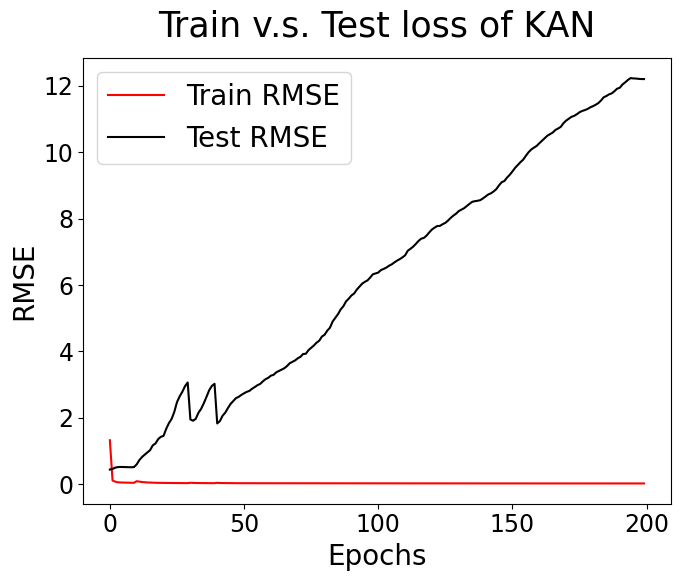

In [14]:
plt.rcParams.update({
    'font.size': 13,          # Global base size
    'axes.titlesize': 25,     # Title size
    'axes.labelsize': 20,     # X and Y axis labels
    'xtick.labelsize': 17,    # X-tick labels
    'ytick.labelsize': 17,    # Y-tick labels
    'legend.fontsize': 20     # Legend font
})

# Load data
data = torch.load(r"4-results\200-epochs-seed-1\static_kan_A.pt", weights_only=False)
train = data[1][100]['train_losses']
test = data[1][100]['rmses']

# Plotting
fig, ax = plt.subplots(figsize=(7, 6)) # Using subplots handles layout better with large fonts
plt.plot(train, color='red', label='Train RMSE')
plt.plot(test, color='black', label='Test RMSE')

# ─── FIXED SYNTAX LINES ───
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Train v.s. Test loss of KAN', pad=15)
plt.legend()

plt.savefig('overfitting behaviour')
plt.tight_layout()
plt.show()

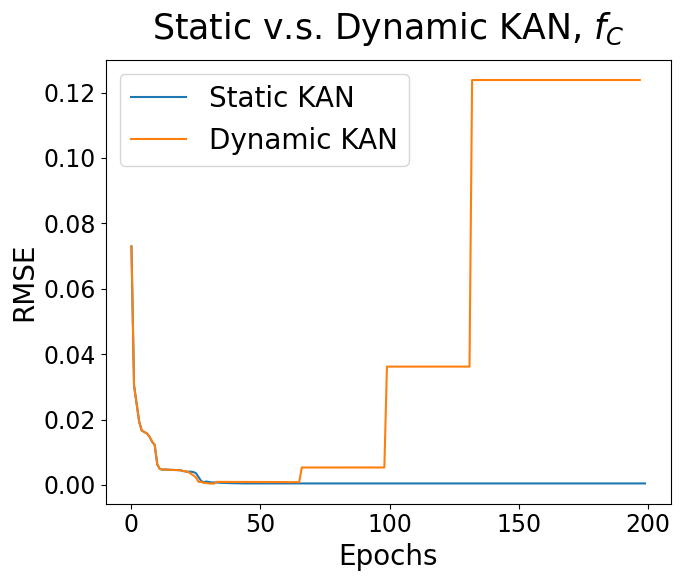

In [15]:
plt.rcParams.update({
    'font.size': 13,          # Global base size
    'axes.titlesize': 25,     # Title size
    'axes.labelsize': 20,     # X and Y axis labels
    'xtick.labelsize': 17,    # X-tick labels
    'ytick.labelsize': 17,    # Y-tick labels
    'legend.fontsize': 20     # Legend font
})
# Load data
static = torch.load(r"4-results\200-epochs-seed-1\static_kan_C.pt", weights_only=False)[1][5]['rmses']
dyn = torch.load(r"4-results\200-epochs-seed-1\dyn_kan_C.pt", weights_only=False)[1][5]['rmses']

# Plotting
fig, ax = plt.subplots(figsize=(7, 6)) # Using subplots handles layout better with large fonts
plt.plot(static, label='Static KAN')
plt.plot(dyn, label='Dynamic KAN')

# ─── FIXED SYNTAX LINES ───
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Static v.s. Dynamic KAN, $f_C$', pad=15)
plt.legend()

plt.savefig('output', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

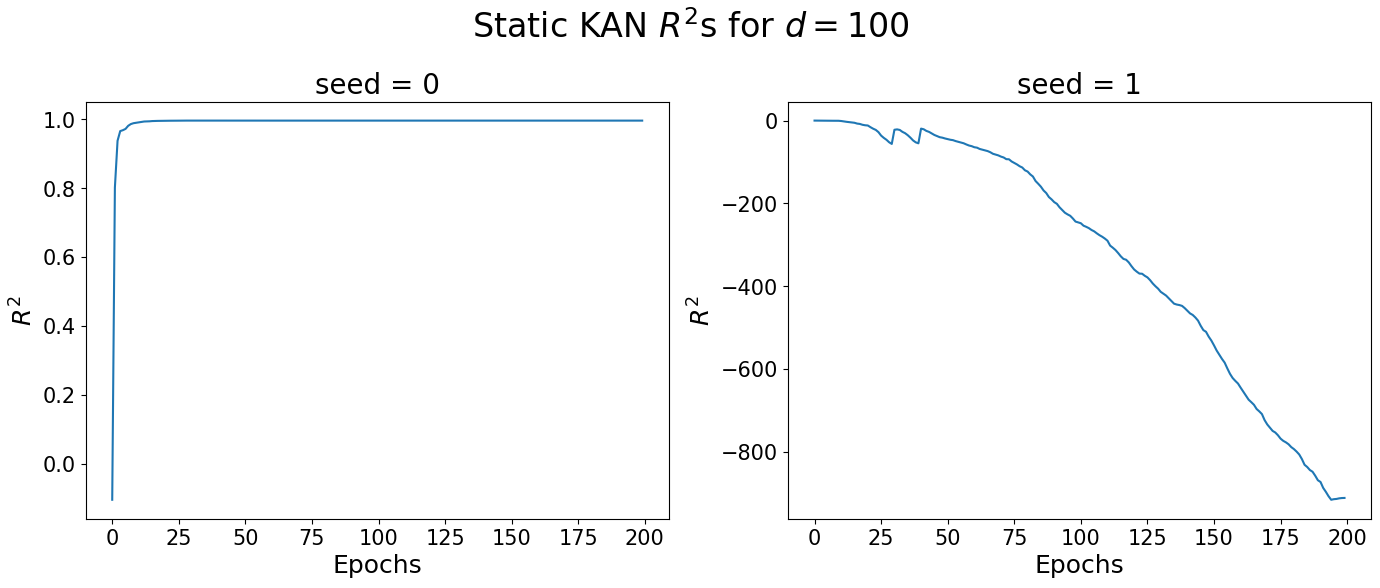

In [27]:
import matplotlib.pyplot as plt
import torch

# Load data
seed0 = torch.load(r"4-results\200-epochs-seed-0\static_kan_A.pt", weights_only=False)[0][100]['r2s']
seed1 = torch.load(r"4-results\200-epochs-seed-1\static_kan_A.pt", weights_only=False)[1][100]['r2s']

# Update plot parameters
plt.rcParams.update({
    'font.size': 13,          
    'axes.titlesize': 20,     
    'axes.labelsize': 18,     
    'xtick.labelsize': 15,    
    'ytick.labelsize': 15,    
    'legend.fontsize': 16     
})

# ─── SIDE-BY-SIDE PLOTTING (INDEPENDENT AXES) ───
# Removed sharey=True so each plot auto-scales its own ticks
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Plot 1: Seed 0
ax0.plot(seed0, label='Static KAN', color='tab:blue') # Matching color
ax0.set_title('seed = 0')
ax0.set_xlabel('Epochs')
ax0.set_ylabel(r'$R^2$')
# ax0.legend()

# Plot 2: Seed 1
ax1.plot(seed1, label='Static KAN', color='tab:blue') # Matching color
ax1.set_title('seed = 1')
ax1.set_xlabel('Epochs')
ax1.set_ylabel(r'$R^2$') # Added Y-label back since axes are independent
# ax1.legend()

# Global Main Title
fig.suptitle(r'Static KAN $R^2$s for $d=100$', fontsize=24)

# Save and show clean layout
plt.tight_layout()
plt.savefig('static_kan_r2_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\runan\AppData\Local\Temp\ipykernel_33360\624738677.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


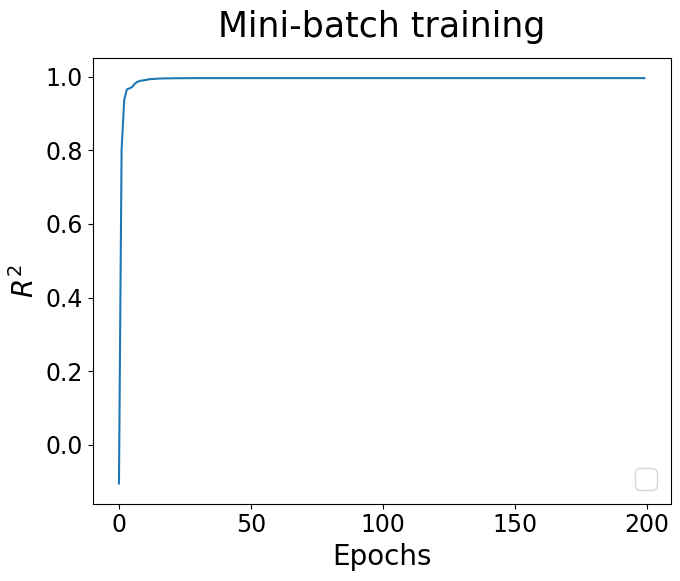

In [ ]:

# Load data
data = torch.load(r"4-results\200-epochs-seed-0\static_kan_A.pt", weights_only=False)
test = data[0][100]['r2s']
plt.rcParams.update({
    'font.size': 13,          # Global base size
    'axes.titlesize': 25,     # Title size
    'axes.labelsize': 20,     # X and Y axis labels
    'xtick.labelsize': 17,    # X-tick labels
    'ytick.labelsize': 17,    # Y-tick labels
    'legend.fontsize': 20     # Legend font
})

# Plotting
fig, ax = plt.subplots(figsize=(7, 6)) # Using subplots handles layout better with large fonts
plt.plot(test)

# ─── FIXED SYNTAX LINES ───
plt.xlabel('Epochs')
plt.ylabel('$R^2$')
plt.title("Mini-batch training", pad=15)
plt.legend()

plt.savefig('overfitting behaviour')
plt.tight_layout()
plt.show()